# Les URH — croisement sols × occupation pour MGB-SA

**Projet** : transport de sédiments dans le Magdalena avec MGB-SED.
Ce notebook explique, à la main et en Python simple, la **deuxième entrée structurante** du modèle (après les minibacias) :
les **URH** — Unités de Réponse Hydrologique.

On réutilise les minibacias obtenues dans le notebook précédent (prétraitement du MNT), et on ajoute deux cartes :
les **sols** et l'**occupation du sol**. Le but est de comprendre :

1. *pourquoi* on croise ces deux cartes (et pas une seule) ;
2. la **mécanique du croisement** (reclassement + superposition cellule par cellule) ;
3. pourquoi les totaux marginaux ne suffisent pas — les **bornes de Fréchet** ;
4. comment on obtient la **composition en URH** de chaque minibacia ;
5. comment cette composition **alimente** le bilan d'eau du MGB-SA.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

nrows, ncols = 6, 6

def montre(g, titre, cmap="tab10"):
    fig, ax = plt.subplots(figsize=(4.6,4.6))
    im = ax.imshow(g, cmap=cmap)
    for (i,j),v in np.ndenumerate(g):
        ax.text(j,i,str(int(v)),ha="center",va="center",fontsize=11,fontweight="bold")
    ax.set_title(titre); ax.set_xticks(range(ncols)); ax.set_yticks(range(nrows))
    plt.tight_layout(); plt.show()


## 1. Pourquoi les URH ?

Une minibacia n'est **pas homogène** : à l'intérieur, sols et couvertures varient, et ne transforment pas la pluie
de la même manière. Modéliser chaque pixel un par un serait trop coûteux. L'idée du MGB : **regrouper les pixels
qui réagissent pareil** en un petit nombre de classes, les URH.

Deux facteurs gouvernent la transformation pluie → écoulement, d'où le croisement de **deux** cartes :

- le **sol** contrôle l'infiltration et le stockage d'eau (une argile sature vite et ruisselle ; un sable infiltre) ;
- l'**occupation** contrôle l'interception, l'évapotranspiration et la rugosité (forêt = évapore/retient ; sol nu = ruisselle).

Deux pixels de *même sol et même couverture* → même réponse → **même URH**. C'est la définition.


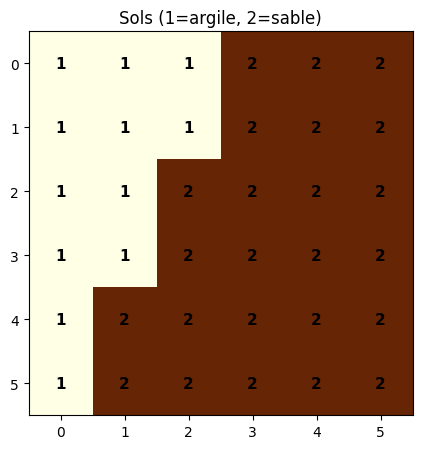

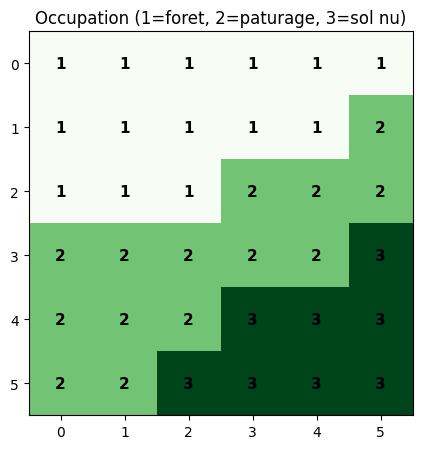

In [2]:
# --- Minibacias : resultat du notebook precedent (etape 7) ---
minibacia = np.array([
 [1,1,2,2,2,2],
 [1,1,1,2,2,2],
 [1,1,1,2,2,2],
 [3,1,3,1,2,2],
 [3,3,3,3,1,2],
 [3,3,3,3,3,4]])

# --- Carte des SOLS (1 = argile, 2 = sable) ---
sol = np.array([
 [1,1,1,2,2,2],
 [1,1,1,2,2,2],
 [1,1,2,2,2,2],
 [1,1,2,2,2,2],
 [1,2,2,2,2,2],
 [1,2,2,2,2,2]])

# --- Carte d'OCCUPATION (1 = foret, 2 = paturage, 3 = sol nu) ---
occ = np.array([
 [1,1,1,1,1,1],
 [1,1,1,1,1,2],
 [1,1,1,2,2,2],
 [2,2,2,2,2,3],
 [2,2,2,3,3,3],
 [2,2,3,3,3,3]])

montre(sol, "Sols (1=argile, 2=sable)", "YlOrBr")
montre(occ, "Occupation (1=foret, 2=paturage, 3=sol nu)", "Greens")


## 2. Le croisement : reclassement puis superposition

En pratique on **reclasse** d'abord chaque carte en quelques classes hydrologiques (ici c'est déjà fait : 2 sols, 3 occupations),
puis on **superpose cellule par cellule**. À chaque couple (sol, occupation) on associe un identifiant d'URH.

Avec $N_{sol}$ classes de sol et $N_{occ}$ classes d'occupation, une formule d'indice pratique est :

$$\text{URH}(i,j) = \big(\text{sol}(i,j) - 1\big)\cdot N_{occ} + \text{occ}(i,j)$$

Le nombre d'URH possibles est **borné** par le produit :

$$N_{URH} \le N_{sol}\times N_{occ}$$

(ici au plus $2\times 3 = 6$). Sur le vrai Magdalena, c'est pour ça qu'on reclasse en *peu* de classes : sinon le produit explose
et on obtient des centaines d'URH ingérables.


Grille URH :
[[1 1 1 4 4 4]
 [1 1 1 4 4 5]
 [1 1 4 5 5 5]
 [2 2 5 5 5 6]
 [2 5 5 6 6 6]
 [2 5 6 6 6 6]]


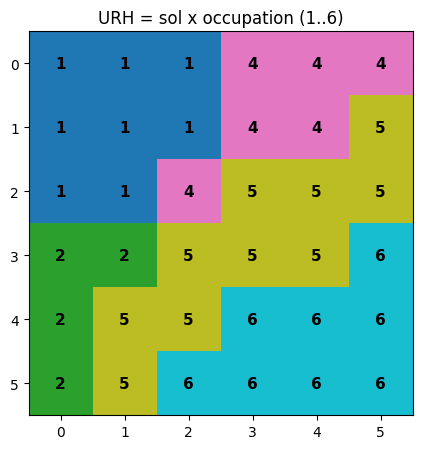

In [3]:
N_occ = 3   # nombre de classes d'occupation

urh = np.zeros((nrows, ncols), dtype=int)
for i in range(nrows):
    for j in range(ncols):
        urh[i][j] = (sol[i][j] - 1) * N_occ + occ[i][j]

noms = {1:"argile+foret",2:"argile+pat",3:"argile+solnu",
        4:"sable+foret", 5:"sable+pat", 6:"sable+solnu"}
print("Grille URH :"); print(urh)
montre(urh, "URH = sol x occupation (1..6)", "tab10")


## 3. Prérequis : l'alignement des cartes

La superposition cellule par cellule n'a de sens que si les cartes **partagent exactement la même grille** :
même **projection**, même **résolution**, même **emprise**, alignées sur la grille du MNT.

C'est l'équivalent, pour les URH, du « NODATA = -9999 » du notebook MNT : un prérequis de cohérence des données.
Dans QGIS, on **rééchantillonne** (resample) sols et occupation sur la grille du MNT avant de croiser. Sinon la case (i,j)
de la carte des sols ne correspond pas au même terrain que la case (i,j) de l'occupation, et l'URH obtenue est fausse.


## 4. Pourquoi les totaux marginaux ne suffisent pas — bornes de Fréchet

Tentation naturelle : « si je connais le % de chaque sol et le % de chaque occupation, je connais le % de chaque URH ».
**Faux.** Les totaux (dits *marginaux*) disent *combien* de chaque type, pas *où* — donc rien sur le **recouvrement**.

Soit une minibacia de $N$ cellules, $a$ cellules d'argile et $b$ cellules de forêt. Le nombre de cellules
« argile ET forêt » (= URH 1) n'est pas déterminé ; il est seulement **encadré** par les **bornes de Fréchet** :

$$\max(0,\; a + b - N)\;\le\; |\text{argile}\cap\text{foret}|\;\le\; \min(a,\,b)$$

- borne haute $\min(a,b)$ : au mieux, toute l'argile est sous forêt ;
- borne basse $\max(0,a+b-N)$ : au pire, on éloigne au maximum les deux.

Seule la **vraie superposition spatiale** tranche à l'intérieur de cet intervalle.


In [4]:
# Demonstration : N=100, a=60 (argile), b=70 (foret)
N, a, b = 100, 60, 70
borne_basse = max(0, a + b - N)
borne_haute = min(a, b)
print("URH 'argile+foret' est forcement entre", borne_basse, "et", borne_haute, "cellules")
print("-> indetermine a partir des seuls totaux (60 argile, 70 foret).")

# Deux dispositions differentes, MEMES marginaux, recouvrements differents
recouvrement_max = np.zeros((10,10),dtype=int)
recouvrement_max[:6,:] = 1                     # 60 argile en haut
foret = np.zeros((10,10),dtype=int); foret[:7,:] = 1   # 70 foret en haut
inter_max = np.sum((recouvrement_max==1) & (foret==1))
print("Disposition 'empilee' -> recouvrement =", inter_max, "(= borne haute)")


URH 'argile+foret' est forcement entre 30 et 60 cellules
-> indetermine a partir des seuls totaux (60 argile, 70 foret).
Disposition 'empilee' -> recouvrement = 60 (= borne haute)


## 5. Composition en URH de chaque minibacia

Une fois la grille d'URH obtenue, on ne garde **pas une carte** par minibacia mais un **vecteur de fractions**.
Pour la minibacia $m$ et l'URH $u$ :

$$f_{m,u} = \frac{\#\{\text{cellules de } m \text{ appartenant à l'URH } u\}}{\#\{\text{cellules de } m\}},
\qquad \sum_{u} f_{m,u} = 1$$

C'est cette table (une ligne par minibacia, une colonne par URH) qui entre dans le MGB.


In [5]:
print("Composition par minibacia (fractions de surface) :")
compo = {}
for mb in range(1, minibacia.max()+1):
    masque = (minibacia == mb)
    total = masque.sum()
    compo[mb] = {}
    print("\nMinibacia %d  (%d cellules) :" % (mb, total))
    for u in range(1, 7):
        n = int(np.sum(urh[masque] == u))
        if n > 0:
            f = n/total
            compo[mb][u] = f
            print("   URH %d %-13s : %5.1f %%" % (u, noms[u], 100*f))
    # verification : la somme des fractions vaut 1
    print("   somme des fractions =", round(sum(compo[mb].values()), 3))


Composition par minibacia (fractions de surface) :

Minibacia 1  (11 cellules) :
   URH 1 argile+foret  :  63.6 %
   URH 2 argile+pat    :   9.1 %
   URH 4 sable+foret   :   9.1 %
   URH 5 sable+pat     :   9.1 %
   URH 6 sable+solnu   :   9.1 %
   somme des fractions = 1.0

Minibacia 2  (13 cellules) :
   URH 1 argile+foret  :   7.7 %
   URH 4 sable+foret   :  38.5 %
   URH 5 sable+pat     :  38.5 %
   URH 6 sable+solnu   :  15.4 %
   somme des fractions = 1.0

Minibacia 3  (11 cellules) :
   URH 2 argile+pat    :  27.3 %
   URH 5 sable+pat     :  36.4 %
   URH 6 sable+solnu   :  36.4 %
   somme des fractions = 1.0

Minibacia 4  (1 cellules) :
   URH 6 sable+solnu   : 100.0 %
   somme des fractions = 1.0


## 6. Comment l'URH alimente le bilan d'eau du MGB-SA

Chaque **classe** d'URH porte un jeu de paramètres fixes : capacité de stockage du sol $W_m$, paramètre de forme $b$,
et des paramètres de végétation (indice foliaire LAI, albédo, résistance de canopée, profondeur racinaire).

Le MGB calcule le bilan d'eau **séparément pour chaque URH présente** dans une minibacia, puis **agrège** en pondérant
par les fractions $f_{m,u}$. Pour n'importe quel flux $X$ (ruissellement, évapotranspiration, écoulement…) :

$$X_m \;=\; \sum_{u} f_{m,u}\, X_u$$

**Aperçu du bilan par URH** (détaillé dans le bloc hydrologie) : le MGB utilise un modèle de sol à **aire contributive
variable** (type Xinanjiang/ARNO). La fraction saturée du sol, qui génère le ruissellement de surface, croît avec le
remplissage $W/W_m$ :

$$A_{sat} \;=\; 1 - \left(1 - \frac{W}{W_m}\right)^{b}$$

Plus le sol est plein, plus $A_{sat}$ est grande, plus la pluie ruisselle. C'est ici que les paramètres propres à chaque URH
(donc au couple sol × occupation) font la différence — et c'est ce ruissellement qui, plus tard, nourrira MUSLE côté sédiments.


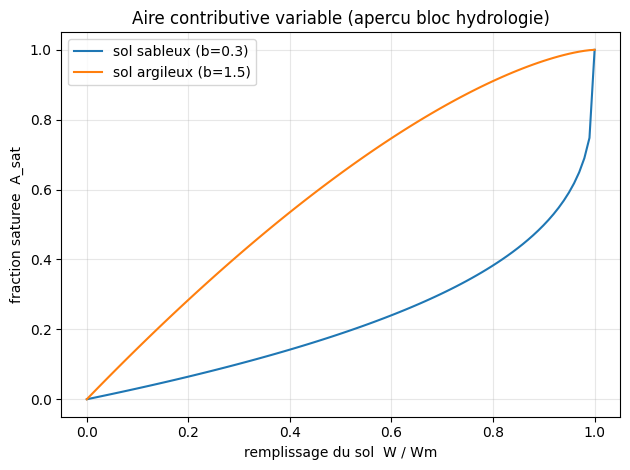

In [6]:
# Illustration : courbe d'aire saturee pour deux URH (b different)
W_sur_Wm = np.linspace(0, 1, 100)
for b_urh, label in [(0.3, "sol sableux (b=0.3)"), (1.5, "sol argileux (b=1.5)")]:
    A_sat = 1 - (1 - W_sur_Wm)**b_urh
    plt.plot(W_sur_Wm, A_sat, label=label)
plt.xlabel("remplissage du sol  W / Wm"); plt.ylabel("fraction saturee  A_sat")
plt.title("Aire contributive variable (apercu bloc hydrologie)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Du DEM-jouet au vrai Magdalena

Même logique à l'échelle réelle ; seul le **prétraitement des deux cartes** change :

- **Sols** : carte IGAC → reclassée en quelques groupes hydrologiques (souvent d'après texture / capacité d'infiltration).
- **Occupation** : ESA WorldCover (ou IDEAM) → reclassée en quelques classes (forêt, cultures, pâturage, urbain, eau…).
- **Alignement** : rééchantillonner les deux sur la grille du MNT (même projection, résolution, emprise).
- **Croisement** : le plugin MGB fait la superposition et le comptage par minibacia automatiquement → **table des URH**.

Ensuite, chaque URH reçoit ses paramètres, et le calage hydrologique (débits IDEAM) ajuste ces paramètres **avant** de passer
aux sédiments. Ce notebook rend transparent *ce que fait* l'outil ; il ne le remplace pas.
